In [1]:
# Canonical routing evaluation (aligned with `notebooks/evaluate_routing.py`)
# Evaluates ML-routing vs hop-count baseline across test runs & timesteps.

import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

ROOT = Path("..").resolve()
os.chdir(ROOT)
print("CWD:", Path.cwd())

sys.path.append(str(Path("src").resolve()))
from routing_from_dataset import DatasetRouter

DATASET_PATH = "dataset/manet_featured_dataset.csv"
TEST_RUNS = [25, 26, 27, 28, 29, 30]
PAIRS_PER_STEP = 5
RADIUS = 250.0
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

os.makedirs("assets", exist_ok=True)


In [11]:
# Load dataset (featured) and prepare test subset (aligned with evaluate_routing.py)

router = DatasetRouter()

df = pd.read_csv(DATASET_PATH)

test_df = df[df["run_id"].isin(TEST_RUNS)].copy()
all_times = sorted(test_df["time"].unique())
all_runs = sorted(test_df["run_id"].unique())

print("Rows (full):", len(df))
print("Rows (test):", len(test_df))
print("Test runs:", all_runs)
print("Timesteps:", len(all_times), f"({all_times[0]} → {all_times[-1]})")

test_df.head()

Rows: 54000
Unique runs: 30
Unique timestamps: 60


,run_id,time,node_id,x,y,neighbor_count,avg_rssi,tx_packets,rx_packets,lost_packets,delay_sum,link_failure
0,9,1.0,0.0,72.955,1.839,1.0,-3.993,0,0,0,0.0,1
1,9,1.0,1.0,477.050,418.620,3.0,-37.570,0,0,0,0.0,0
2,9,1.0,2.0,22.462,160.934,2.0,-41.436,0,0,0,0.0,1
3,9,1.0,3.0,477.311,378.324,2.0,-35.513,0,0,0,0.0,0
4,9,1.0,4.0,272.095,354.846,0.0,-1000.000,0,0,0,0.0,1


In [12]:
# Evaluation loop (aligned with `notebooks/evaluate_routing.py`)

print("=" * 65)
print("MANET Routing Evaluation — ML vs Hop-Count Baseline")
print("=" * 65)

records = []

for run_id in all_runs:
    run_df = test_df[test_df["run_id"] == run_id]
    times = sorted(run_df["time"].unique())
    print(f"\n  Run {run_id} — {len(times)} timesteps")

    for t in times:
        snapshot = run_df[run_df["time"] == t].copy().reset_index(drop=True)

        try:
            G_ml, G_base, pos = router.build_graph(snapshot, radius=RADIUS)
        except Exception as e:
            print(f"    t={t}: graph build failed ({e}), skipping.")
            continue

        if G_ml.number_of_edges() == 0:
            continue

        nodes = list(G_ml.nodes())
        if len(nodes) < 2:
            continue

        pairs_tried = 0
        pairs_done = 0

        while pairs_done < PAIRS_PER_STEP and pairs_tried < 50:
            pairs_tried += 1
            src, dst = random.sample(nodes, 2)

            ml_path = router.find_ml_path(G_ml, src, dst)
            base_path = router.find_baseline_path(G_base, src, dst)

            if ml_path is None or base_path is None:
                continue

            ml_m = router.compute_route_metrics(G_ml, ml_path)
            base_m = router.compute_route_metrics(G_ml, base_path)

            records.append({
                "run_id": run_id,
                "time": t,
                "source": src,
                "target": dst,
                "ml_avg_reliability": ml_m["avg_reliability"],
                "ml_min_reliability": ml_m["min_reliability"],
                "ml_hops": ml_m["hop_count"],
                "base_avg_reliability": base_m["avg_reliability"],
                "base_min_reliability": base_m["min_reliability"],
                "base_hops": base_m["hop_count"],
            })
            pairs_done += 1

        print(f"    t={t:.1f}: {pairs_done} pairs evaluated, edges={G_ml.number_of_edges()}", end="\r")

print(f"\n\nTotal routing decisions recorded: {len(records)}")

results = pd.DataFrame(records)
results.head()

Loading models...
Models loaded successfully.
Predictor ready


In [ ]:
# Graph builder - this reconstructs the network topology at each time step

def build_graph(snapshot, radius = 100):

    G = nx.Graph()

    rows = snapshot.to_dict("records")

    for r in rows:
        G.add_node(int(r["node_id"]), x = r["x"], y = r["y"])

    edge_features = []
    edge_pairs = []

    for i in range(len(rows)):
        for j in range(i+1, len(rows)):

            n1 = int(rows[i]["node_id"])
            n2 = int(rows[j]["node_id"])

            x1,y1 = rows[i]["x"], rows[i]["y"]
            x2,y2 = rows[j]["x"], rows[j]["y"]

            dist = np.sqrt((x1-x2)**2 + (y1-y2)**2)

            if dist <= radius:

                features = [
                    rows[i]["neighbor_count"],
                    rows[i]["x"],
                    rows[i]["y"],
                    rows[i]["time"]
                ]

                edge_pairs.append((n1,n2))
                edge_features.append(features)

    if len(edge_features) > 0:

        X = np.array(edge_features)

        reliabilities,_ = predictor.predict(X)

        for (u,v),r in zip(edge_pairs,reliabilities):

            r = float(r)

            weight = 1/(r+1e-9)

            G.add_edge(u,v,reliability = r,weight = weight)

    return G

In [ ]:
# Routing metric computation

def route_metrics(G, source, target):

    result = {}

    try:
        baseline = nx.shortest_path(G,source,target)
    except:
        baseline = None

    try:
        ml = nx.shortest_path(G,source,target,weight="weight")
    except:
        ml = None

    result["baseline_path"] = baseline
    result["ml_path"] = ml

    if baseline:

        rel = [G[u][v]["reliability"] for u,v in zip(baseline[:-1],baseline[1:])]

        result["baseline_hops"] = len(baseline) - 1
        result["baseline_mean_rel"] = np.mean(rel)
        result["baseline_min_rel"] = np.min(rel)

    if ml:

        rel = [G[u][v]["reliability"] for u,v in zip(ml[:-1],ml[1:])]

        result["ml_hops"] = len(ml) - 1
        result["ml_mean_rel"] = np.mean(rel)
        result["ml_min_rel"] = np.min(rel)

    return result

In [10]:
# Evaluate across all timestamps

SOURCE = 0
TARGET = 5

times = sorted(df["time"].unique())

records = []

prev_baseline = None
prev_ml = None

for t in tqdm(times):

    snapshot = df[df["time"] == t]

    G = build_graph(snapshot)

    metrics = route_metrics(G,SOURCE,TARGET)

    metrics["time"] = t

    records.append(metrics)

results = pd.DataFrame(records)

results = results.dropna(subset = ["baseline_mean_rel","ml_mean_rel"])

results.head()

100%|██████████| 60/60 [00:32<00:00,  1.84it/s]


,baseline_path,ml_path,time,baseline_hops,baseline_mean_rel,baseline_min_rel,ml_hops,ml_mean_rel,ml_min_rel
6,"[0, 20, 24, 8, 28, 5]","[0, 20, 24, 6, 29, 11, 5]",7.0,5.0,0.606683,0.360758,6.0,0.761862,0.360758
7,"[0, 16, 24, 8, 11, 5]","[0, 20, 24, 29, 11, 5]",8.0,5.0,0.602986,0.367190,5.0,0.722988,0.360889
8,"[0, 25, 8, 11, 5]","[0, 20, 24, 28, 11, 5]",9.0,4.0,0.510073,0.358742,5.0,0.715985,0.350011
9,"[0, 16, 8, 11, 5]","[0, 25, 28, 11, 5]",10.0,4.0,0.500382,0.343153,4.0,0.652578,0.343153
10,"[0, 28, 11, 5]","[0, 28, 11, 5]",11.0,3.0,0.556790,0.350977,3.0,0.556790,0.350977


In [13]:
baseline_mean = results["baseline_mean_rel"].mean()
ml_mean = results["ml_mean_rel"].mean()

baseline_min = results["baseline_min_rel"].mean()
ml_min = results["ml_min_rel"].mean()

baseline_hops = results["baseline_hops"].mean()
ml_hops = results["ml_hops"].mean()

improvement = (ml_mean-baseline_mean)/baseline_mean*100

print("Average baseline reliability:",round(baseline_mean,3))
print("Average ML reliability:",round(ml_mean,3))
print("Reliability improvement:",round(improvement,2),"%")

print()

print("Average baseline hops:",round(baseline_hops,2))
print("Average ML hops:",round(ml_hops,2))

Average baseline reliability: 0.658
Average ML reliability: 0.723
Reliability improvement: 9.75 %

Average baseline hops: 3.75
Average ML hops: 3.82


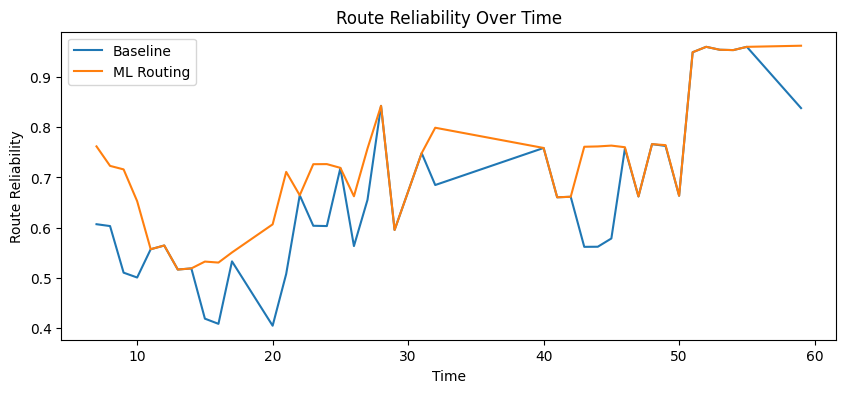

In [14]:
plt.figure(figsize=(10,4))

plt.plot(results["time"],results["baseline_mean_rel"],label="Baseline")
plt.plot(results["time"],results["ml_mean_rel"],label="ML Routing")

plt.xlabel("Time")
plt.ylabel("Route Reliability")

plt.title("Route Reliability Over Time")

plt.legend()
plt.show()

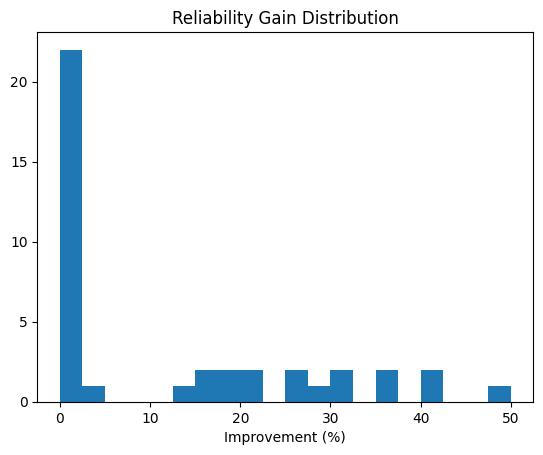

In [15]:
results["gain_pct"] = (
    (results["ml_mean_rel"] - results["baseline_mean_rel"])
    / results["baseline_mean_rel"]
) * 100

plt.hist(results["gain_pct"].dropna(),bins = 20)

plt.title("Reliability Gain Distribution")
plt.xlabel("Improvement (%)")

plt.show()

In [ ]:
# Aggregate metrics + plots + save artifacts (aligned with `notebooks/evaluate_routing.py`)

if len(results) == 0:
    raise RuntimeError(
        "No records collected. Likely causes: models/predict shape mismatch, or radius too small."
    )

print("\n" + "=" * 65)
print("Aggregate Results")
print("=" * 65)

ml_avg_rel = results["ml_avg_reliability"].mean()
base_avg_rel = results["base_avg_reliability"].mean()
ml_min_rel = results["ml_min_reliability"].mean()
base_min_rel = results["base_min_reliability"].mean()
ml_hops = results["ml_hops"].mean()
base_hops = results["base_hops"].mean()

rel_improvement = (ml_avg_rel - base_avg_rel) / base_avg_rel * 100
min_improvement = (ml_min_rel - base_min_rel) / base_min_rel * 100

print(f"\n  {'Metric':<30} {'Baseline':>10} {'ML Routing':>12} {'Δ':>8}")
print(f"  {'─'*30} {'─'*10} {'─'*12} {'─'*8}")
print(
    f"  {'Avg Route Reliability':<30} {base_avg_rel:>10.4f} {ml_avg_rel:>12.4f} {rel_improvement:>+7.1f}%"
)
print(
    f"  {'Min Link Reliability':<30} {base_min_rel:>10.4f} {ml_min_rel:>12.4f} {min_improvement:>+7.1f}%"
)
print(
    f"  {'Avg Hop Count':<30} {base_hops:>10.4f} {ml_hops:>12.4f} {ml_hops - base_hops:>+8.2f}"
)

# Statistical significance
_, p_value = stats.ttest_rel(results["ml_avg_reliability"], results["base_avg_reliability"])
print(f"\n  Paired t-test p-value: {p_value:.6f}")

# Per-run summary
per_run = results.groupby("run_id")[["ml_avg_reliability", "base_avg_reliability"]].mean()
per_run["improvement_%"] = (
    (per_run["ml_avg_reliability"] - per_run["base_avg_reliability"]) / per_run["base_avg_reliability"] * 100
)
print(per_run.round(4).to_string())

# Time series for plots
time_series = (
    results.groupby("time")
    .agg(
        ml_avg_rel=("ml_avg_reliability", "mean"),
        base_avg_rel=("base_avg_reliability", "mean"),
        ml_min_rel=("ml_min_reliability", "mean"),
        base_min_rel=("base_min_reliability", "mean"),
        ml_hops=("ml_hops", "mean"),
        base_hops=("base_hops", "mean"),
    )
    .reset_index()
)

fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)
ML_COLOR, BASE_COLOR = "#2196F3", "#9C27B0"

ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(time_series["time"], time_series["ml_avg_rel"], color=ML_COLOR, lw=2.5, label="ML Routing")
ax1.plot(time_series["time"], time_series["base_avg_rel"], color=BASE_COLOR, lw=2.5, linestyle="--", label="Baseline")
ax1.set_title("Average Route Reliability over Time", fontweight="bold")
ax1.legend(); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 2])
ax2.bar([str(r) for r in per_run.index], per_run["improvement_%"], color=ML_COLOR)
ax2.set_title("Per-Run Improvement (%)", fontweight="bold")

plot_path = "assets/routing_evaluation.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"\n  Plots saved to {plot_path}")

results.to_csv("dataset/routing_results.csv", index=False)
print("  EVALUATION COMPLETE")
